In [70]:
%matplotlib inline
from __future__ import division
import matplotlib
import numpy as np
from pylab import *
from mpl_toolkits.mplot3d import Axes3D
import h5py
import os
import re
matplotlib.rcParams.update({"axes.formatter.limits": (-4,4)})
plotStyles={"markersize":20,"markeredgewidth":3.0,"linewidth":3.0}
stepStyles={"markersize":20,"markeredgewidth":3.0,"linewidth":3.0,"where":"post"}
np.seterr(divide='ignore',invalid='ignore')
pass

### Execute with time limit.

In [200]:
%%bash
dirname=data/1
filename=${dirname}/first_order_birth_death.lm
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} first_order_birth_death.sbml
lm_setp ${filename} writeInterval=1e-2 maxTime=1e1
echo "Execute the following command in `pwd`:"
lmes -r 1-1000 -f ${filename} -gr 0 -c 2  -sl lm::avx::GillespieDSolverAVX > ${filename}.log
echo "Finished."

lm_sbml_import v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


Done.
lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting parameters in simulation file data/1/first_order_birth_death.lm:
maxTime=1e1
writeInterval=1e-2
Done.
Execute the following command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/first_order_birth_death:
Finished.


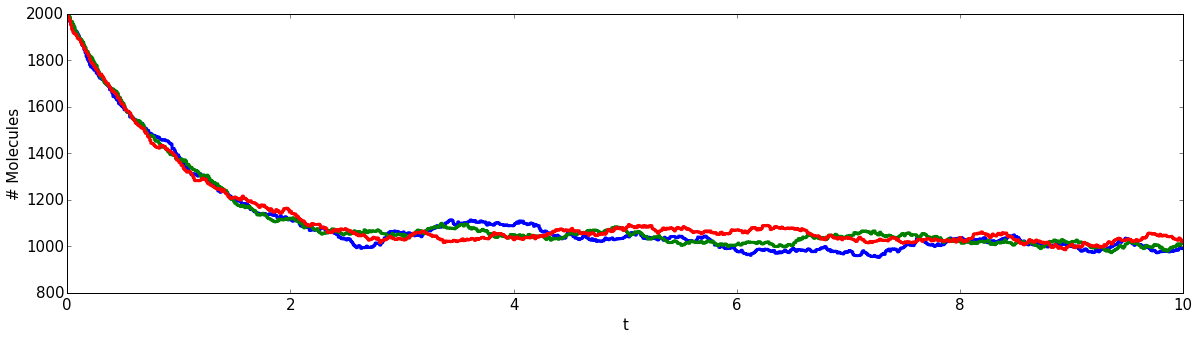

In [201]:
# Plot the time series for a set of replicates.
dirname="data/1"
filename="%s/first_order_birth_death.lm"%dirname
fp = h5py.File(filename, "r")
matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (20,5)})
for replicate in (1,2,3):
    counts=np.array(fp["/Simulations/%07d/SpeciesCounts"%replicate], dtype=double)
    times=np.array(fp["/Simulations/%07d/SpeciesCountTimes"%replicate], dtype=double)
    step(times,counts[:,0], **stepStyles)
xlabel('t'); ylabel('# Molecules')
pass

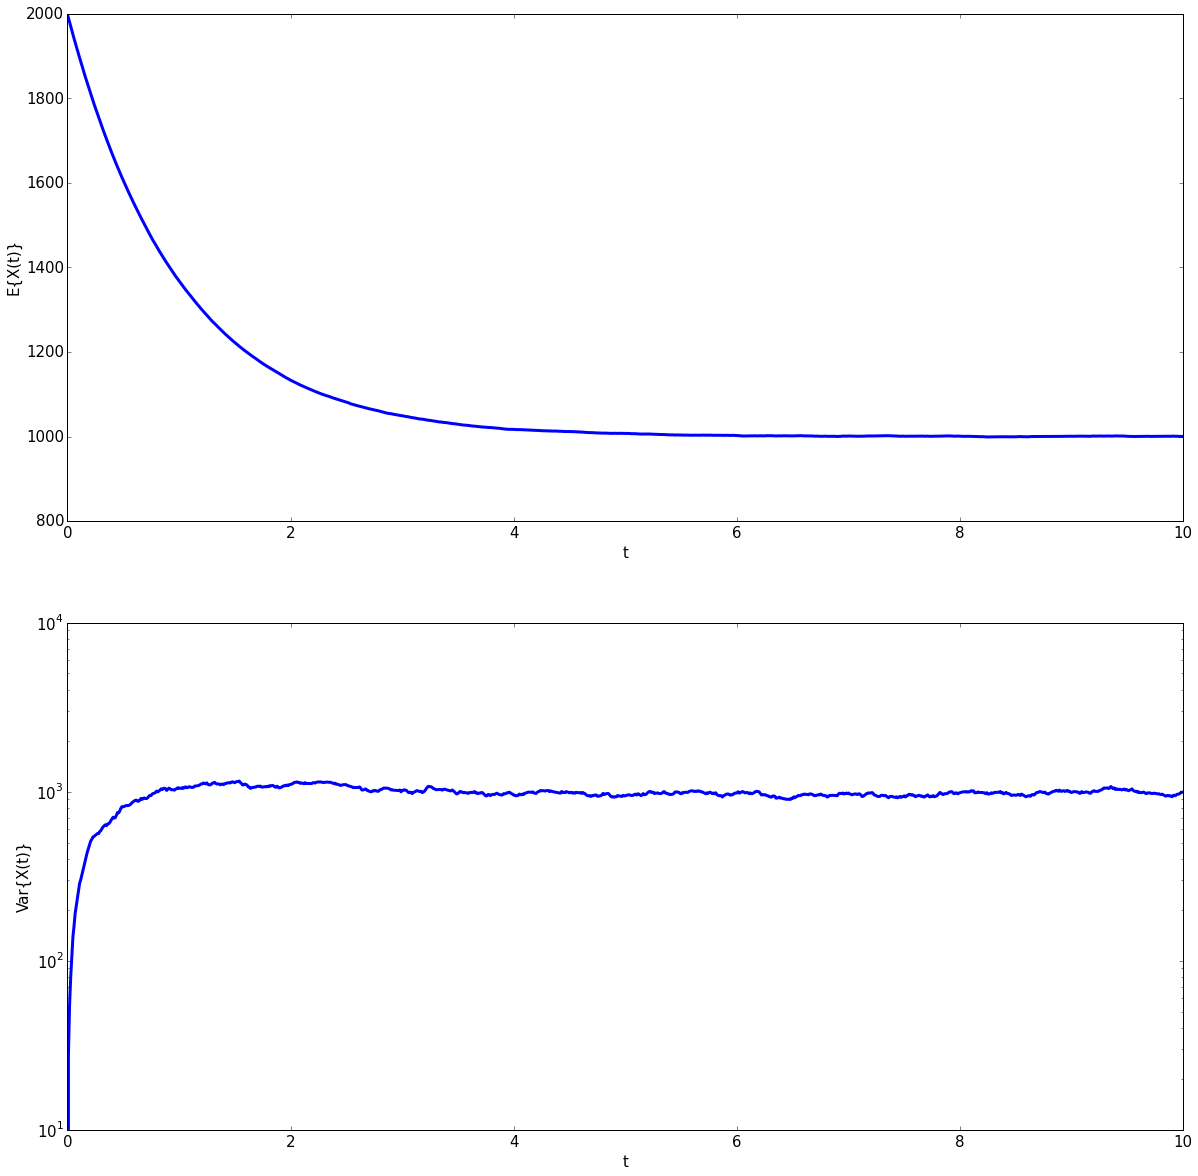

In [202]:
# Plot the mean and variance.
dirname="data/1"
filename="%s/first_order_birth_death.lm"%dirname
fp = h5py.File(filename, "r")
replicates=fp["/Simulations"].keys()
k=0
mSim=None
vSim=None
times=None
for replicate in replicates:
    if times is None:
        times = np.array(fp["/Simulations/%s/SpeciesCountTimes"%replicate], dtype=double)
    counts = np.array(fp["/Simulations/%s/SpeciesCounts"%replicate], dtype=double)
    if mSim is None:
        k += 1
        mSim = counts
        vSim = np.zeros(counts.shape, dtype=double)
    else:
        k += 1
        mSim = mSim + (counts-mSim)/k
        vSim = vSim + (counts-mSim)*(counts-mSim)
vSim /= float((k-1))

matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (20,20)})
ax=plt.subplot(2,1,1)
plt.plot(times,mSim[:,0], **plotStyles)
ax.set_yscale('linear'); xlabel('t'); ylabel('E{X(t)}')

ax=plt.subplot(2,1,2)
plt.plot(times,vSim[:,0], **plotStyles)
ax.set_yscale('log'); xlabel('t'); ylabel('Var{X(t)}')
pass

### Execute with lower species limit

In [140]:
%%bash
dirname=data/2
filename=${dirname}/first_order_birth_death.lm
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} first_order_birth_death.sbml
lm_setp ${filename} writeInterval=1e-2 "speciesLowerLimitList=0:900"
echo "Execute the following command in `pwd`:"
lmes -r 1-1000 -f ${filename} -gr 0 -c 2 > ${filename}.log
echo "Finished."

lm_sbml_import v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


Done.
lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting parameters in simulation file data/2/first_order_birth_death.lm:
speciesLowerLimitList=0:900
writeInterval=1e-2
Done.
Execute the following command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/first_order_birth_death:
Finished.


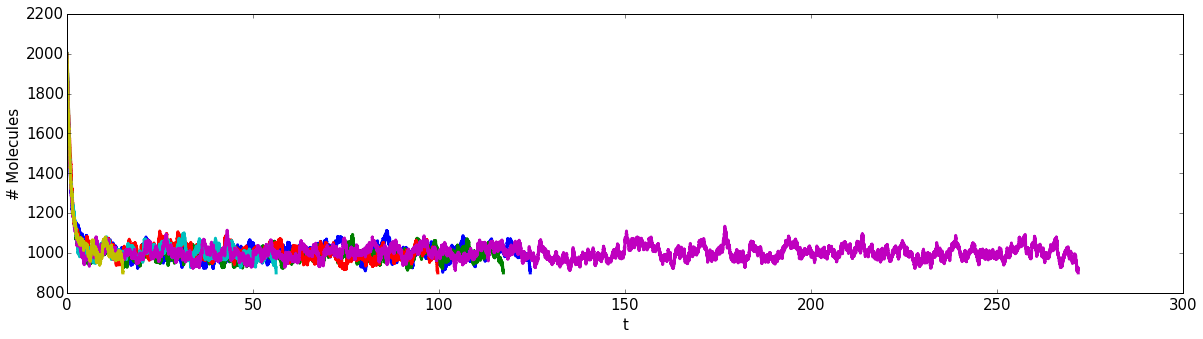

In [141]:
# Plot the time series for a set of replicates.
dirname="data/2"
filename="%s/first_order_birth_death.lm"%dirname
fp = h5py.File(filename, "r")
matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (20,5)})
for replicate in (1,2,3,4,5,6):
    counts=fp["/Simulations/%07d/SpeciesCounts"%replicate]
    times=fp["/Simulations/%07d/SpeciesCountTimes"%replicate]
    step(times,counts, **stepStyles)
xlabel('t'); ylabel('# Molecules')
pass

ERROR! Session/line number was not unique in database. History logging moved to new session 177


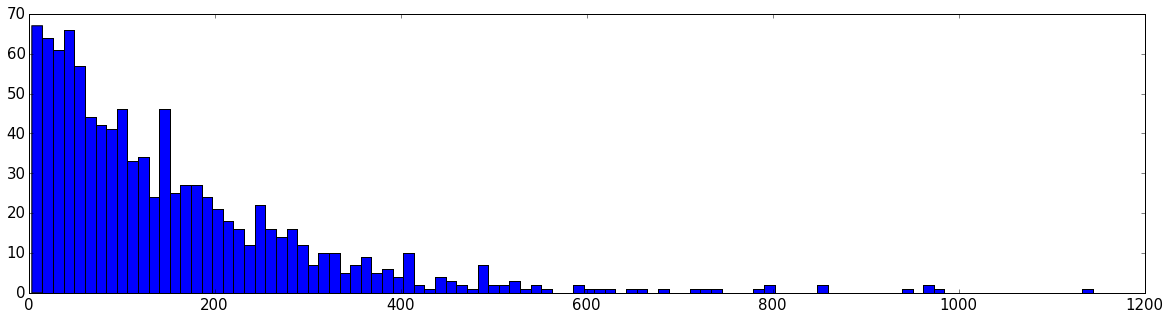

In [146]:
# Plot the final times.
dirname="data/2"
filename="%s/first_order_birth_death.lm"%dirname
fp = h5py.File(filename, "r")
replicates=fp["/Simulations"].keys()
finalTimes=[]
for replicate in replicates:
    counts = fp["/Simulations/%s/SpeciesCounts"%replicate]
    times = fp["/Simulations/%s/SpeciesCountTimes"%replicate]
    if counts[-1] != 900:
        print "Final count was not correct %d=%d"%(replicate,counts[-1])
    else:
        finalTimes.append(times[-1])
matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (20,5)})
hist(finalTimes,100)
pass

### Execute with upper species limit

In [169]:
%%bash
dirname=data/3
filename=${dirname}/first_order_birth_death.lm
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} first_order_birth_death.sbml
lm_setp ${filename} writeInterval=1e0  maxTime=1e1 "speciesUpperLimitList=0:2002"
echo "Execute the following command in `pwd`:"
lmes -r 1-1000 -f ${filename} -gr 0 -c 2 > ${filename}.log
echo "Finished."

lm_sbml_import v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


Done.
lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting parameters in simulation file data/3/first_order_birth_death.lm:
maxTime=1e1
speciesUpperLimitList=0:2002
writeInterval=1e0
Done.
Execute the following command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/first_order_birth_death:
Finished.


269 of 1000 replicates reached the limit


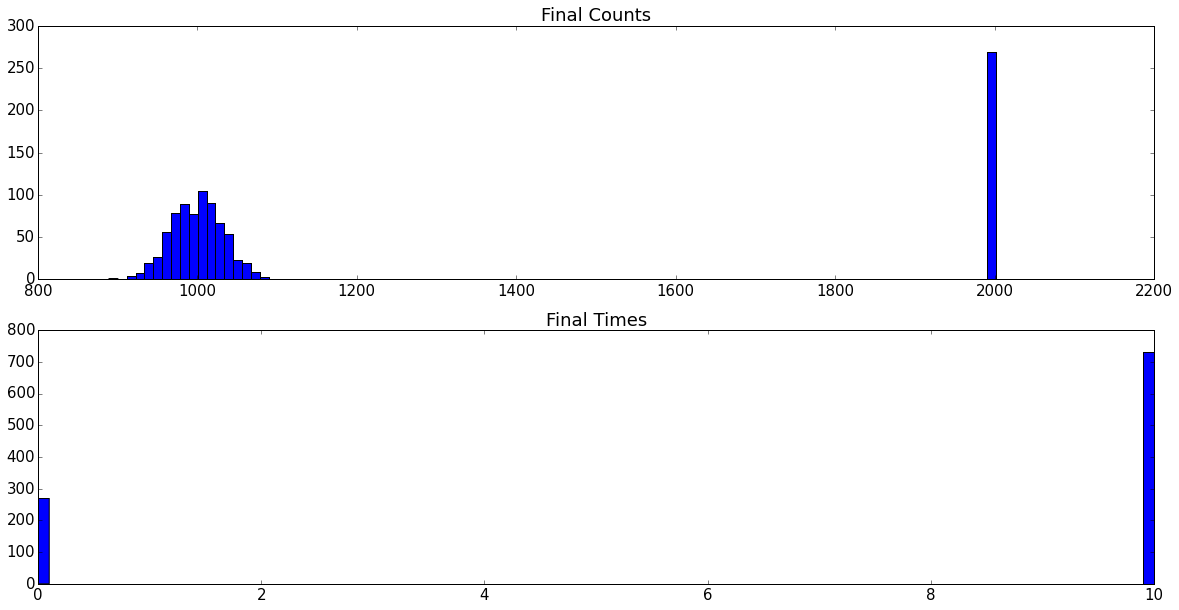

In [166]:
# Plot the final times.
dirname="data/3"
filename="%s/first_order_birth_death.lm"%dirname
fp = h5py.File(filename, "r")
replicates=fp["/Simulations"].keys()
finalTimes=[]
finalCounts=[]
limitReached=0
for replicate in replicates:
    counts = np.array(fp["/Simulations/%s/SpeciesCounts"%replicate])
    times = np.array(fp["/Simulations/%s/SpeciesCountTimes"%replicate])
    finalCounts.append(counts[-1,0])
    if counts[-1,0] == 2002:
        limitReached+=1
    finalTimes.append(times[-1])
matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (20,10)})
ax=plt.subplot(2,1,1)
hist(finalCounts,100)
title("Final Counts")
ax=plt.subplot(2,1,2)
title("Final Times")
hist(finalTimes,100)
print "%d of %d replicates reached the limit"%(limitReached,len(replicates))
pass

### Execute with fpt tracking

In [286]:
%%bash
dirname=data/4
filename=${dirname}/first_order_birth_death.lm
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} first_order_birth_death.sbml
lm_setp ${filename} writeInterval=1e0 maxTime=1e1  fptTrackingList=0
echo "Execute the following command in `pwd`:"
lmes -r 1-10000 -f ${filename} -gr 0 -c 2 -sl lm::cme::GillespieDSolver > ${filename}.log
echo "Finished."

lm_sbml_import v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


Done.
lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting parameters in simulation file data/4/first_order_birth_death.lm:
fptTrackingList=0
maxTime=1e1
writeInterval=1e0
Done.
Execute the following command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/first_order_birth_death:
Finished.


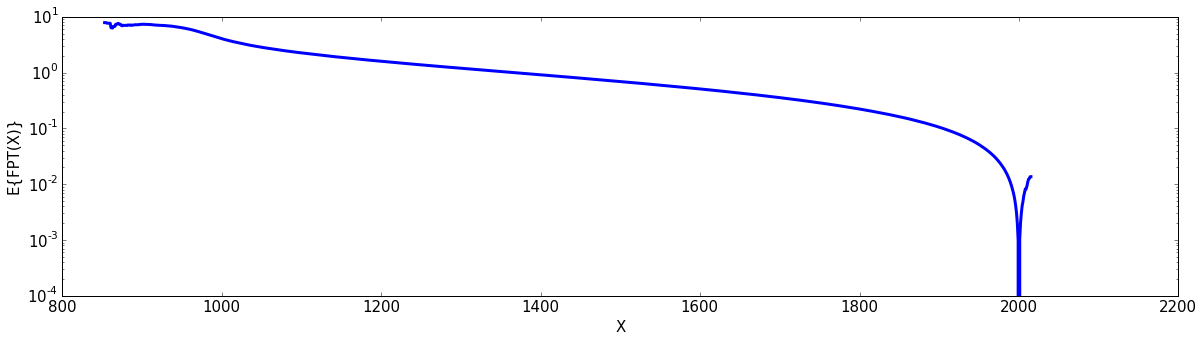

In [287]:
# Plot the mean first passage times.
dirname="data/4"
filename="%s/first_order_birth_death.lm"%dirname
fp = h5py.File(filename, "r")
replicates=fp["/Simulations"].keys()
counts=None
times=None
allCounts = np.zeros((2100,), dtype=double)
allTimes = np.zeros((2100,), dtype=double)
for replicate in replicates:
    counts=np.array(fp["/Simulations/%s/FirstPassageTimes/00/Counts"%replicate], dtype=double)
    times=np.array(fp["/Simulations/%s/FirstPassageTimes/00/Times"%replicate], dtype=double)
    start = int(counts[0])
    end = start+counts.shape[0]
    allCounts[start:end] += 1    
    allTimes[start:end] += times
allTimes /= allCounts
matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (20,5)})
ax=plt.subplot(1,1,1)
plt.plot(np.arange(0,2100, dtype=double),allTimes, **plotStyles)
ax.set_yscale('log'); xlabel('X'); ylabel('E{FPT(X)}')
pass

### Performance comparison
Generate the input files and output the commands to run the simulations.

In [253]:
%%bash
dirname=data/perf.99.latest
filename=${dirname}/first_order_birth_death.lm
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} first_order_birth_death.sbml
lm_setp ${filename} writeInterval=1e4 maxTime=1e5
echo "Execute the following command in `pwd`:"
echo 'for replicate in `seq -f "%g" 0 10`; do'
echo "echo Running \${replicate};"
#echo "hostname=\`hostname\`"
#echo "lmesPrefix=/share/git/LatticeMicrobesES/build/"
#echo "hostname=barkeri"
#echo "lmesPrefix="
echo "hostname=marcc"
echo "lmesPrefix=/home-2/erober32@jhu.edu/share/git/LatticeMicrobesES/build-icc/"
#echo "\${lmesPrefix}lmes -r 1-15 -f ${filename} -c 2 -gr 0 -ff null -sl lm::cme::GillespieDSolver| tee ${filename}.\${hostname}.\${replicate}.log";
echo "\${lmesPrefix}lmes -r 1-15 -f ${filename} -c 2 -gr 0 -ff null -sl lm::avx::GillespieDSolverAVX| tee ${filename}.\${hostname}.\${replicate}.log";
echo 'done;'


lm_sbml_import v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


Done.
lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting parameters in simulation file data/perf.99.latest/first_order_birth_death.lm:
maxTime=1e5
writeInterval=1e4
Done.
Execute the following command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/first_order_birth_death:
for replicate in `seq -f "%g" 0 15`; do
echo Running ${replicate};
hostname=marcc
lmesPrefix=/home-2/erober32@jhu.edu/share/git/LatticeMicrobesES/build-icc/
${lmesPrefix}lmes -r 1-10 -f data/perf.99.latest/first_order_birth_death.lm -c 2 -gr 0 -ff null -sl lm::avx::GillespieDSolverAVX| tee data/perf.99.latest/first_order_birth_death.lm.${hostname}.${replicate}.log
done;


In [277]:
# Extract the timing data.
datadir="data"
timingData={}
testNumberMap={}
regex0 = re.compile("perf\.(\d+).(\S+)")
regex1 = re.compile("\.lm\.([^\.]+)\.(\d+)\.log")
regex2 = re.compile("Finished .+ seconds \((\S+) steps/second\)")
for dirname in os.listdir(datadir):
    testName = None
    m = regex0.search(dirname)
    if m != None:
        testNumber = m.group(1)
        testName = m.group(2)
        testNumberMap[testNumber] = testName
    if testName is not None:
        for logname in os.listdir(datadir+"/"+dirname):
            m = regex1.search(logname)
            if m != None:
                host=m.group(1)
                replicate=int(m.group(2))
                with open(datadir+"/"+dirname+"/"+logname) as f:
                    for line in f:
                        m = regex2.search(line)
                        if m != None:
                            if host not in timingData:
                                timingData[host]={}
                            if testName not in timingData[host]:
                                timingData[host][testName]=[]
                            timingData[host][testName].append(double(m.group(1)))
                            break

In [230]:
print timingData

{'xanthus-cp-2': {'propensity_as_static_functions': [13430000.0, 13400000.0, 13480000.0, 13550000.0, 13350000.0, 13400000.0, 13880000.0, 13530000.0, 13420000.0, 13000000.0, 13350000.0], 'propensity_as_virtual_methods': [14170000.0, 14280000.0, 13560000.0, 14250000.0, 14260000.0, 14260000.0, 14120000.0, 14200000.0, 14270000.0, 14160000.0, 14060000.0], 'multi_part_work_units': [13230000.0, 13270000.0, 13200000.0, 13350000.0, 13320000.0, 13310000.0, 13180000.0, 13280000.0, 13320000.0, 13210000.0, 13260000.0], 'latest': [17330000.0, 17500000.0, 17260000.0, 17130000.0, 17930000.0, 17170000.0, 17320000.0]}, 'barkeri': {'propensity_as_static_functions': [17680000.0, 17730000.0, 17690000.0, 17600000.0, 17560000.0, 17550000.0, 17680000.0, 17810000.0, 17810000.0, 17750000.0, 17760000.0], 'propensity_as_virtual_methods': [20290000.0, 20650000.0, 20680000.0, 20200000.0, 20590000.0, 20600000.0, 20700000.0, 20680000.0, 20690000.0, 20450000.0, 20680000.0], 'multi_part_work_units': [20160000.0, 198000

[35293636.363636367, 33424375.0, 17377142.857142858, 19931250.0]


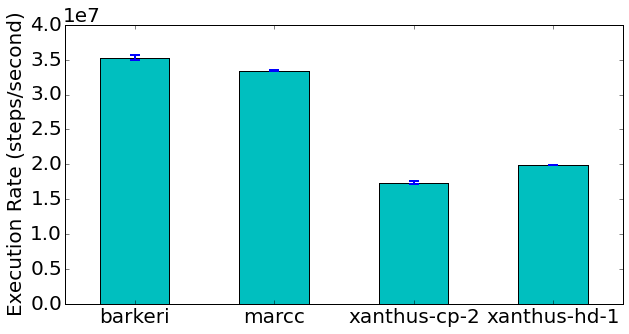

In [255]:
# Plot the latest timing data.
matplotlib.rcParams.update({'font.size': 20, "figure.figsize": (10,5)})
hosts = timingData.keys()
hosts.sort()
times=[]
timesErr=[]
for host in hosts:
    if "latest" in timingData[host]:
        times.append(mean(timingData[host]['latest']))
        timesErr.append(std(timingData[host]['latest']))
print times
plt.bar(arange(0,len(hosts))+0.25,times,width=0.5,yerr=timesErr, color='c', error_kw={"elinewidth":2,"capsize":5,"capthick":2})
plt.ylabel('Execution Rate (steps/second)')
plt.xticks(arange(0,len(hosts))+0.5, hosts)
plt.ylim([0,4e7])
pass

[17692727.272727273, 20564545.454545453, 20097272.727272727, 35293636.363636367]
[10250000.0, 17858181.818181816, 33424375.0]
[13435454.545454545, 14144545.454545455, 13266363.636363637, 17377142.857142858]
[16380000.0, 17122727.272727273, 16185454.545454545, 19931250.0]


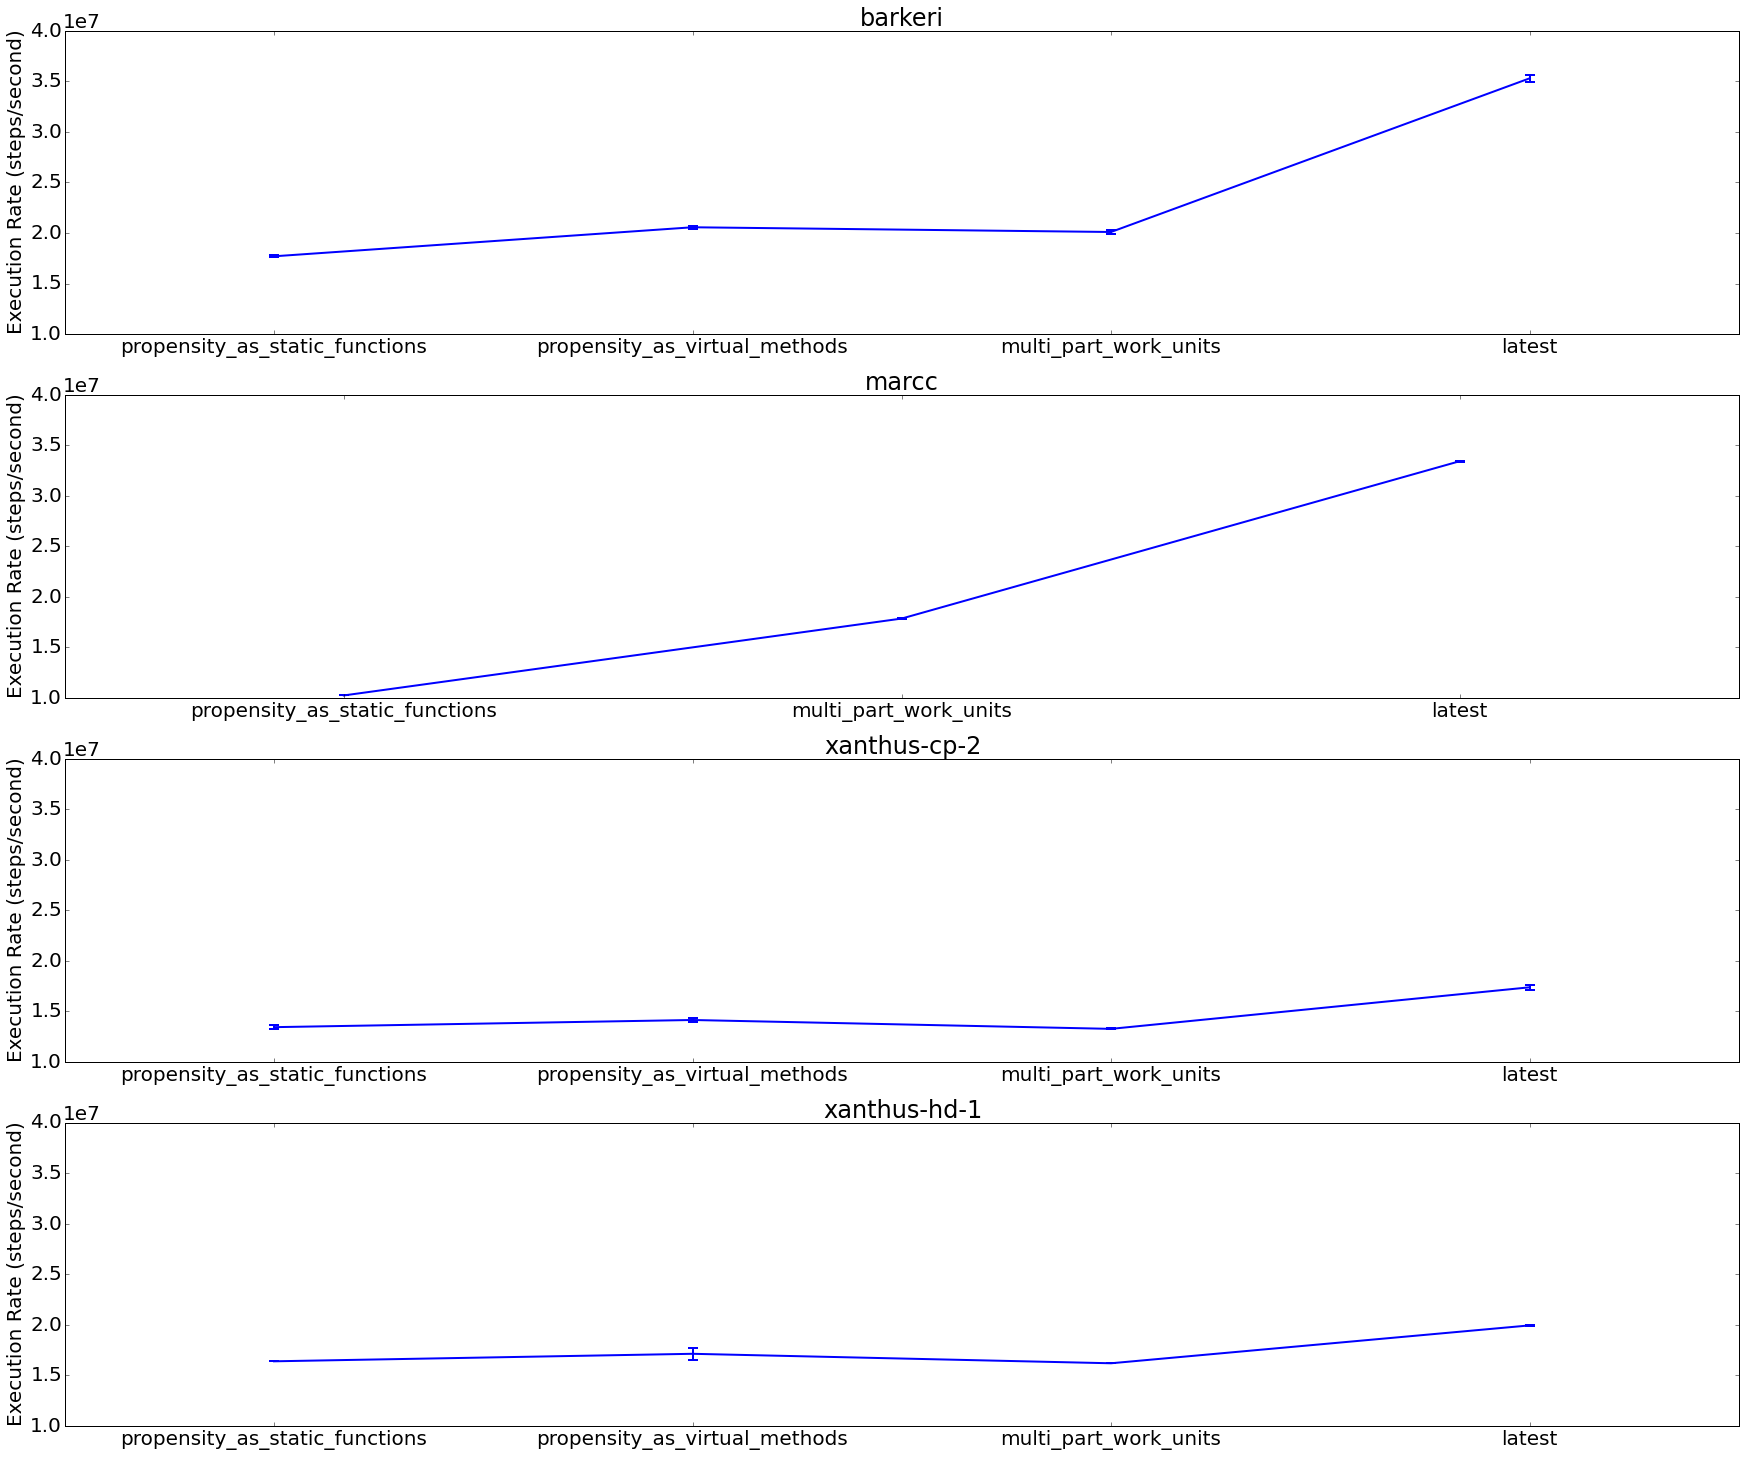

In [258]:
# Plot the previous timing data.
matplotlib.rcParams.update({'font.size': 20, "figure.figsize": (30,25)})
hosts = timingData.keys()
hosts.sort()
testNumbers = testNumberMap.keys()
testNumbers.sort()
for i,host in enumerate(hosts):
    times=[]
    timesErr=[]
    testNames=[]
    for testNumber in testNumbers:
        testName = testNumberMap[testNumber]
        if testName in timingData[host]:
            times.append(mean(timingData[host][testName]))
            timesErr.append(std(timingData[host][testName]))
            testNames.append(testName)
    plt.subplot(len(hosts),1,i+1)
    plt.errorbar(arange(0,len(testNames))+0.5,times,linewidth=2,yerr=timesErr,elinewidth=2,capsize=5,capthick=2)
    plt.ylabel('Execution Rate (steps/second)')
    plt.xticks(arange(0,len(testNames))+0.5, testNames)
    plt.xlim([0,len(testNames)]); plt.ylim([1e7,4e7])
    plt.title(host)
    print times
pass

### Performance comparison with a fully utilized node

In [274]:
%%bash
dirname=data/perf_full.99.latest
filename=${dirname}/first_order_birth_death.lm
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} first_order_birth_death.sbml
lm_setp ${filename} writeInterval=1e4 maxTime=1e5
cpus=24
trajectories=$((15*cpus))
echo "Execute the following command in `pwd`:"
echo "trajectories=${trajectories};"
echo 'for replicate in `seq -f "%g" 0 10`; do'
echo "echo Running \${replicate};"
#echo "hostname=\`hostname\`"
#echo "lmesPrefix=/share/git/LatticeMicrobesES/build/"
#echo "hostname=barkeri"
#echo "lmesPrefix="
echo "hostname=marcc"
echo "lmesPrefix=/home-2/erober32@jhu.edu/share/git/LatticeMicrobesES/build-icc/"
#echo "\${lmesPrefix}lmes -r 1-${trajectories} -f ${filename} -c ${cpus} -gr 0 -ff null -sl lm::cme::GillespieDSolver| tee ${filename}.\${hostname}.\${replicate}.log";
echo "\${lmesPrefix}lmes -r 1-${trajectories} -f ${filename} -c ${cpus} -gr 0 -ff null -sl lm::avx::GillespieDSolverAVX| tee ${filename}.\${hostname}.\${replicate}.log";
echo 'done;'


lm_sbml_import v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


Done.
lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting parameters in simulation file data/perf_full.99.latest/first_order_birth_death.lm:
maxTime=1e5
writeInterval=1e4
Done.
Execute the following command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/first_order_birth_death:
trajectories=360;
for replicate in `seq -f "%g" 0 10`; do
echo Running ${replicate};
hostname=marcc
lmesPrefix=/home-2/erober32@jhu.edu/share/git/LatticeMicrobesES/build-icc/
${lmesPrefix}lmes -r 1-360 -f data/perf_full.99.latest/first_order_birth_death.lm -c 24 -gr 0 -ff null -sl lm::avx::GillespieDSolverAVX| tee data/perf_full.99.latest/first_order_birth_death.lm.${hostname}.${replicate}.log
done;


In [279]:
# Extract the timing data.
datadir="data"
timingDataFull={}
testNumberMapFull={}
regex0 = re.compile("perf_full\.(\d+).(\S+)")
regex1 = re.compile("\.lm\.([^\.]+)\.(\d+)\.log")
regex2 = re.compile("Finished .+ seconds \((\S+) steps/second\)")
for dirname in os.listdir(datadir):
    testName = None
    m = regex0.search(dirname)
    if m != None:
        testNumber = m.group(1)
        testName = m.group(2)
        testNumberMapFull[testNumber] = testName
    if testName is not None:
        for logname in os.listdir(datadir+"/"+dirname):
            m = regex1.search(logname)
            if m != None:
                host=m.group(1)
                replicate=int(m.group(2))
                with open(datadir+"/"+dirname+"/"+logname) as f:
                    for line in f:
                        m = regex2.search(line)
                        if m != None:
                            if host not in timingDataFull:
                                timingDataFull[host]={}
                            if testName not in timingDataFull[host]:
                                timingDataFull[host][testName]=[]
                            timingDataFull[host][testName].append(double(m.group(1)))
                            break

[33424375.0, 33419090.90909091]


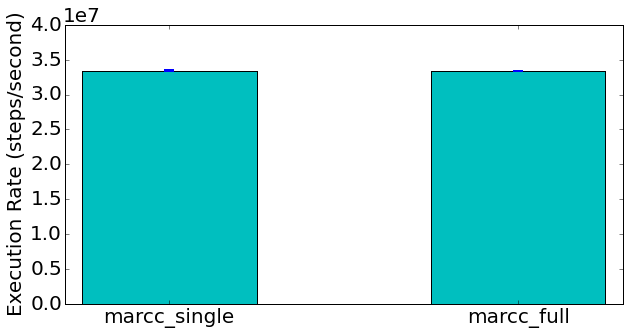

In [285]:
# Plot the latest timing data.
matplotlib.rcParams.update({'font.size': 20, "figure.figsize": (10,5)})
hosts = timingDataFull.keys()
hosts.sort()
times=[]
timesErr=[]
plotHosts=[]
for host in hosts:
    if "latest" in timingDataFull[host]:
        times.append(mean(timingData[host]['latest']))
        timesErr.append(std(timingData[host]['latest']))
        plotHosts.append("%s_%s"%(host,"single"))
        times.append(mean(timingDataFull[host]['latest']))
        timesErr.append(std(timingDataFull[host]['latest']))
        plotHosts.append("%s_%s"%(host,"full"))
print times
plt.bar(arange(0,len(plotHosts))+0.25,times,width=0.5,yerr=timesErr, color='c', error_kw={"elinewidth":2,"capsize":5,"capthick":2})
plt.ylabel('Execution Rate (steps/second)')
plt.xticks(arange(0,len(plotHosts))+0.5, plotHosts)
plt.ylim([0,4e7])
pass